In [1]:
import requests
import pandas as pd

#Call the FHIR server
url = "https://hapi.fhir.org/baseR4/Patient"
params = {"_count": 20}

response = requests.get(url, params=params)
data = response.json()

# Parse into a list
rows =[]
for entry in data.get("entry", []):
    p = entry["resource"]
    name = p.get("name", [{}])[0]
    rows.append({
        "id": p.get("id"),
        "family": name.get("family"),
        "given": str(name.get("given", [])),
        "gender": p.get("gender"),
        "birthDate": p.get("birthDate")
    })

# Turn into DataFrame
df = pd.DataFrame(rows)
print(df.shape)
df.head(10)


(20, 5)


,id,family,given,gender,birthDate
0,90393039,Karla,['NuÃ±ez'],female,1980-01-02
1,90397171,Karla,['NuÃ±ez'],female,1980-01-02
2,90398324,Karla,['NuÃ±ez'],female,1980-01-02
3,90399233,Karla,['NuÃ±ez'],female,1980-01-02
4,90400394,Karla,['NuÃ±ez'],female,1980-01-02
5,90402134,Karla,['NuÃ±ez'],female,1980-01-02
6,90404501,Karla,['NuÃ±ez'],female,1980-01-02
7,90405596,Karla,['NuÃ±ez'],female,1980-01-02
8,90406644,Karla,['NuÃ±ez'],female,1980-01-02
9,90407555,Karla,['NuÃ±ez'],female,1980-01-02


In [2]:
# Check for missing values and data types
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nGender distribution:")
print(df['gender'].value_counts())

id           object
family       object
given        object
gender       object
birthDate    object
dtype: object

Missing values:
id           0
family       0
given        0
gender       0
birthDate    0
dtype: int64

Gender distribution:
gender
female    20
Name: count, dtype: int64


In [3]:
# Pull observations (vitals + labs)
obs_rows = []

for patient_id in df['id'].dropna():
    obs_url = "https://hapi.fhir.org/baseR4/Observation"
    obs_params = {"patient": patient_id, "_count": 5}
    obs_response = requests.get(obs_url, params=obs_params)
    obs_data = obs_response.json()
    
    for entry in obs_data.get("entry", []):
        o = entry["resource"]
        code = o.get("code", {})
        coding = code.get("coding", [{}])[0]
        value = o.get("valueQuantity", {})
        
        obs_rows.append({
            "patient_id": patient_id,
            "loinc_code": coding.get("code"),
            "display": coding.get("display") or code.get("text"),
            "value": value.get("value"),
            "unit": value.get("unit")
        })

obs_df = pd.DataFrame(obs_rows)
print(obs_df.shape)
obs_df.head(10)

(0, 0)


""


In [4]:
# What LOINC codes appear most frequently?
print(obs_df['display'].value_counts().head(10))

KeyError: 'display'

In [5]:
# Pull observations directly from the server
obs_url = "https://hapi.fhir.org/baseR4/Observation"
obs_params = {"_count": 50, "status": "final"}

obs_response = requests.get(obs_url, params=obs_params)
obs_data = obs_response.json()

obs_rows = []
for entry in obs_data.get("entry", []):
    o = entry["resource"]
    code = o.get("code", {})
    coding = code.get("coding", [{}])[0]
    value = o.get("valueQuantity", {})
    category = o.get("category", [{}])[0].get("coding", [{}])[0]
    
    obs_rows.append({
        "patient_id": o.get("subject", {}).get("reference"),
        "category": category.get("code"),
        "loinc_code": coding.get("code"),
        "display": coding.get("display") or code.get("text"),
        "value": value.get("value"),
        "unit": value.get("unit")
    })

obs_df = pd.DataFrame(obs_rows)
print(obs_df.shape)
obs_df.head(10)

(50, 6)


,patient_id,category,loinc_code,display,value,unit
0,Patient/89181652,None,8310-5,Body temperature,90.0,degF
1,None,vital-signs,8867-4,Heart rate,102.0,/min
2,None,vital-signs,2708-6,saturation in Arterial blood,98.0,%
3,Patient/89980748,None,8867-4,Heart rate,102.0,beats/min
4,Patient/89181703,None,8462-4,Diastolic blood pressure,79.0,mmHg
5,Patient/89980748,None,8310-5,Fever,100.4,degF
6,Patient/89980748,None,8480-6,Diastolic blood pressure,80.0,mmHg
7,Patient/cfsb1761834255983,None,8302-2,Body height,165.0,cm
8,Patient/testmartin,laboratory,718-7,Hemoglobin [Mass/volume] in Blood,14.0,g/dL
9,Patient/testmartin,laboratory,2345-7,Glucose [Mass/volume] in Blood,95.0,mg/dL


In [6]:
print(obs_df['display'].value_counts().head(10))
print("\nCategories found:")
print(obs_df['category'].value_counts())


display
Environmental Air Pollution Exposure            4
Heart rate                                      4
Hemoglobina glicosilada (HbA1c)                 3
Platelets [#/volume] in Blood                   3
Microalbuminuria (orina)                        3
Triglicéridos                                   3
Colesterol LDL                                  3
Creatinina sérica                               3
Glucosa en plasma                               3
Cholesterol [Mass/volume] in Serum or Plasma    3
Name: count, dtype: int64

Categories found:
category
laboratory     30
vital-signs     6
Name: count, dtype: int64


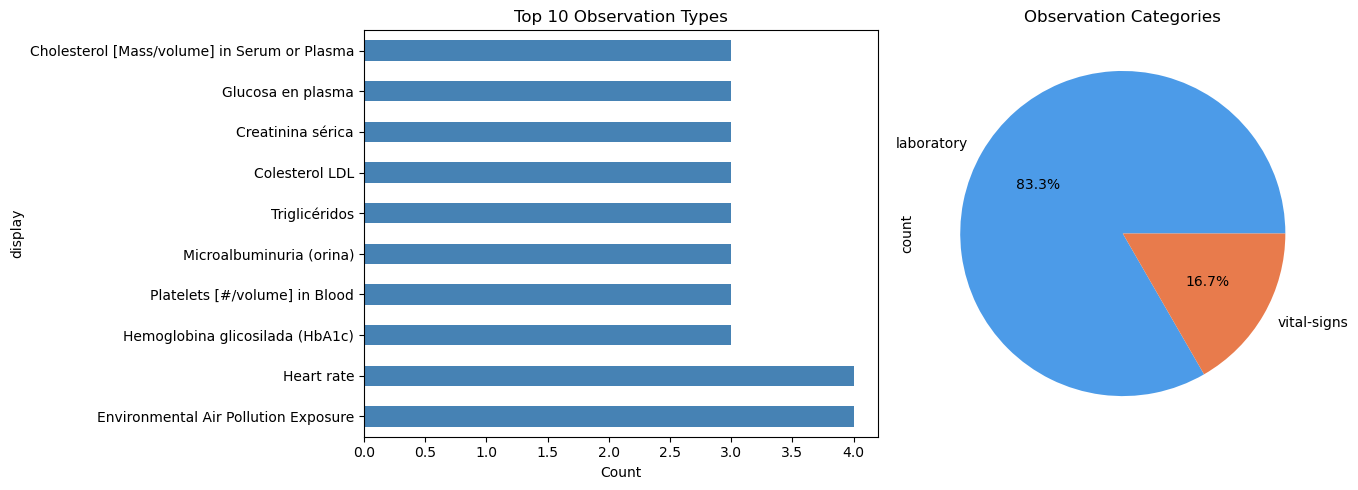

Chart saved!


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Top observations by frequency
obs_df['display'].value_counts().head(10).plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Top 10 Observation Types')
axes[0].set_xlabel('Count')

# Chart 2 — Category breakdown
obs_df['category'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4C9BE8', '#E87B4C']
)
axes[1].set_title('Observation Categories')

plt.tight_layout()
plt.savefig('fhir_observations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")